In [ ]:
# source: https://www.kaggle.com/discussions/general/74235
from google.colab import userdata
import os

os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

# MBTI Datasets
! kaggle datasets download -d "zeyadkhalid/mbti-personality-types-500-dataset" # cleaned personalitycafe + reddit
! kaggle datasets download -d "jhonatanparada/cleaned-mbti-personality-type-twitter-dataset" # cleaned twitter

! unzip "*.zip"

Dataset URL: https://www.kaggle.com/datasets/zeyadkhalid/mbti-personality-types-500-dataset
License(s): CC0-1.0
100% 123M/123M [00:08<00:00, 14.7MB/s]

Dataset URL: https://www.kaggle.com/datasets/jhonatanparada/cleaned-mbti-personality-type-twitter-dataset
License(s): unknown
100% 7.15M/7.15M [00:01<00:00, 7.27MB/s]

Archive:  cleaned-mbti-personality-type-twitter-dataset.zip
  inflating: cleaned_twitter_MBTI.csv  

Archive:  mbti-personality-types-500-dataset.zip
  inflating: MBTI 500.csv            

2 archives were successfully processed.


In [ ]:
import pandas as pd
import numpy as np

# Matplotlib, plt and cm modules
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# the Naive Bayes model
from sklearn.naive_bayes import MultinomialNB                # Classifiers
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import LogisticRegression

# Testing
from sklearn.model_selection import train_test_split

# function for transforming documents into counts
from sklearn.feature_extraction.text import CountVectorizer  # Vectorizer
from sklearn.feature_extraction.text import TfidfTransformer # Transformer
from sklearn.feature_extraction.text import TfidfVectorizer # Transformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import LabelEncoder # function for encoding categories

from sklearn import metrics

DATASETS_PATH = './'

In [ ]:
cleaned_reddit_percafe = pd.read_csv(f'{DATASETS_PATH}MBTI 500.csv')
cleaned_twitter = pd.read_csv(f'{DATASETS_PATH}cleaned_twitter_MBTI.csv')

In [ ]:
print(cleaned_twitter.isnull().sum())

cleaned_twitter

label                    0
ie                       0
ns                       0
tf                       0
jp                       0
lemmatize_clean_posts    0
dtype: int64


,label,ie,ns,tf,jp,lemmatize_clean_posts
0,INTJ,I,N,T,J,the pope be infallible this be a catholic dogm...
1,INTJ,I,N,T,J,be you make you look cute on because then I ca...
2,INTJ,I,N,T,J,les balle sont relle et sont tire tr rapidemen...
3,INTJ,I,N,T,J,I m like entp but idiotic hey boy do you want ...
4,INTJ,I,N,T,J,give it to he have pica since childhood say qu...
...,...,...,...,...,...,...
7806,INTP,I,N,T,P,godpls take care hiro emergency room be you ok...
7807,INTP,I,N,T,P,wow last time I get intp I think u upset the f...
7808,ENTP,E,N,T,P,a that someone will get his ass kick so its ok...
7809,INFJ,I,N,F,J,if you re intj this one be for you what be nev...


In [ ]:
print(cleaned_twitter.isnull().sum())

cleaned_reddit_percafe

label                    0
ie                       0
ns                       0
tf                       0
jp                       0
lemmatize_clean_posts    0
dtype: int64


,posts,type
0,know intj tool use interaction people excuse a...,INTJ
1,rap music ehh opp yeah know valid well know fa...,INTJ
2,preferably p hd low except wew lad video p min...,INTJ
3,drink like wish could drink red wine give head...,INTJ
4,space program ah bad deal meing freelance max ...,INTJ
...,...,...
106062,stay frustrate world life want take long nap w...,INFP
106063,fizzle around time mention sure mistake thing ...,INFP
106064,schedule modify hey w intp strong wing underst...,INFP
106065,enfj since january busy schedule able spend li...,INFP


In [ ]:
# source: https://www.kaggle.com/code/rajshreev/mbti-personality-predictor-using-machine-learning
def get_types(row):
    t=row['type'] # or t

#    I = 0; N = 0
#    T = 0; J = 0

    if t[0] == 'I': I = 'I'
    elif t[0] == 'E': I = 'E'
    else: print('I-E not found')

    if t[1] == 'N': N = 'N'
    elif t[1] == 'S': N = 'S'
    else: print('N-S not found')

    if t[2] == 'T': T = 'T'
    elif t[2] == 'F': T = 'F'
    else: print('T-F not found')

    if t[3] == 'J': J = 'J'
    elif t[3] == 'P': J = 'P'
    else: print('J-P not found')
    return pd.Series( {'ie':I, 'ns':N , 'tf': T, 'jp': J })



## Add Binary columns for MBTI dimensions

In [ ]:
cleaned_reddit_percafe = cleaned_reddit_percafe.join(cleaned_reddit_percafe.apply(
    lambda row: get_types (row),axis=1))

cleaned_reddit_percafe.head(5)


,posts,type,ie,ns,tf,jp
0,know intj tool use interaction people excuse a...,INTJ,I,N,T,J
1,rap music ehh opp yeah know valid well know fa...,INTJ,I,N,T,J
2,preferably p hd low except wew lad video p min...,INTJ,I,N,T,J
3,drink like wish could drink red wine give head...,INTJ,I,N,T,J
4,space program ah bad deal meing freelance max ...,INTJ,I,N,T,J


In [ ]:
# if wanting to export
# data.to_csv("cleaned_twitter_MBTI.csv", index=False)

In [ ]:
# Concatenate or perform union for both datasets

cleaned_twitter = cleaned_twitter.rename(
    columns={'lemmatize_clean_posts': 'posts', 'label': 'type'})

all_datasets = pd.concat([cleaned_reddit_percafe, cleaned_twitter], ignore_index=True)
all_datasets

,posts,type,ie,ns,tf,jp
0,know intj tool use interaction people excuse a...,INTJ,I,N,T,J
1,rap music ehh opp yeah know valid well know fa...,INTJ,I,N,T,J
2,preferably p hd low except wew lad video p min...,INTJ,I,N,T,J
3,drink like wish could drink red wine give head...,INTJ,I,N,T,J
4,space program ah bad deal meing freelance max ...,INTJ,I,N,T,J
...,...,...,...,...,...,...
113873,godpls take care hiro emergency room be you ok...,INTP,I,N,T,P
113874,wow last time I get intp I think u upset the f...,INTP,I,N,T,P
113875,a that someone will get his ass kick so its ok...,ENTP,E,N,T,P
113876,if you re intj this one be for you what be nev...,INFJ,I,N,F,J


## Dataset Visualization

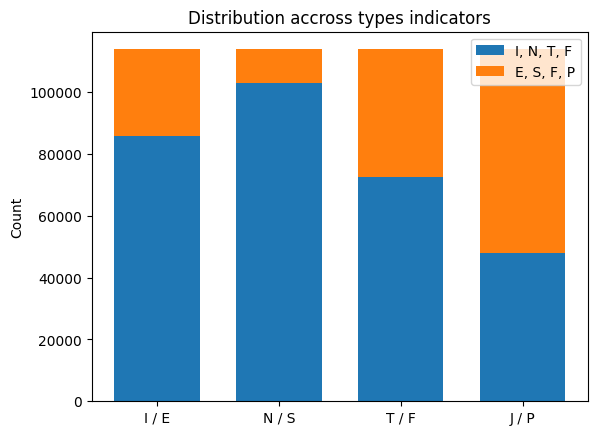

In [ ]:
# Source: https://www.kaggle.com/code/rajshreev/mbti-personality-predictor-using-machine-learning
# Plotting the distribution of each personality type indicator
N = 4
# fixed the values for values counts from digits to the actuall values (I,E,N,S..)
bottom = (all_datasets['ie'].value_counts()['I'], all_datasets['ns'].value_counts()['N'], all_datasets['tf'].value_counts()['T'], all_datasets['jp'].value_counts()['J'])
top = (all_datasets['ie'].value_counts()['E'], all_datasets['ns'].value_counts()['S'], all_datasets['tf'].value_counts()['F'], all_datasets['jp'].value_counts()['P'])

ind = np.arange(N)    # the x locations for the groups
# the width of the bars
width = 0.7           # or len(x) can also be used here

p1 = plt.bar(ind, bottom, width, label="I, N, T, F")
p2 = plt.bar(ind, top, width, bottom=bottom, label="E, S, F, P")

plt.title('Distribution accross types indicators')
plt.ylabel('Count')
plt.xticks(ind, ('I / E',  'N / S', 'T / F', 'J / P',))
plt.legend()

plt.show()

## Binary Classifiers

## Linear Regression Classifier

ie
I    85925
E    27953
Name: count, dtype: int64
Classification report for ie dataset:
              precision    recall  f1-score   support

           E       0.71      0.84      0.77      8386
           I       0.95      0.89      0.92     25778

    accuracy                           0.88     34164
   macro avg       0.83      0.86      0.84     34164
weighted avg       0.89      0.88      0.88     34164




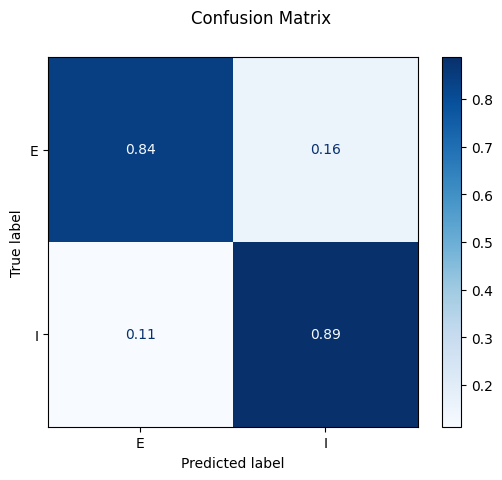

ns
N    102900
S     10978
Name: count, dtype: int64
Classification report for ns dataset:
              precision    recall  f1-score   support

           N       0.98      0.92      0.95     30871
           S       0.54      0.85      0.66      3293

    accuracy                           0.91     34164
   macro avg       0.76      0.89      0.80     34164
weighted avg       0.94      0.91      0.92     34164




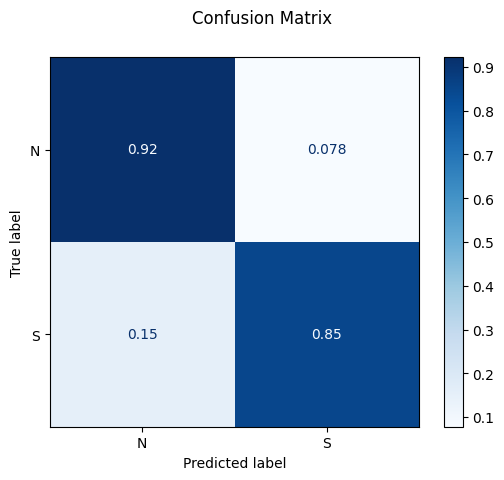

tf
T    72418
F    41460
Name: count, dtype: int64
Classification report for tf dataset:
              precision    recall  f1-score   support

           F       0.85      0.91      0.88     12438
           T       0.95      0.91      0.93     21726

    accuracy                           0.91     34164
   macro avg       0.90      0.91      0.90     34164
weighted avg       0.91      0.91      0.91     34164




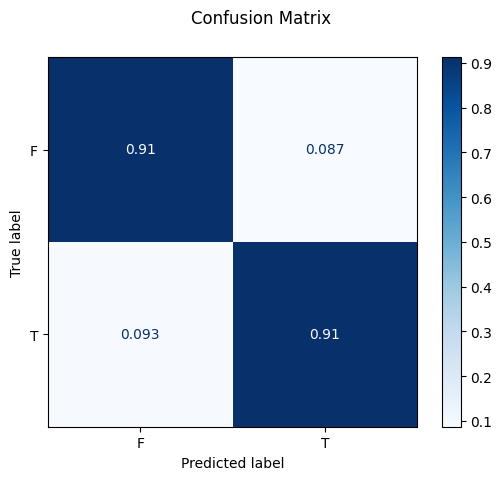

jp
P    65999
J    47879
Name: count, dtype: int64
Classification report for jp dataset:
              precision    recall  f1-score   support

           J       0.81      0.85      0.83     14364
           P       0.88      0.85      0.87     19800

    accuracy                           0.85     34164
   macro avg       0.85      0.85      0.85     34164
weighted avg       0.85      0.85      0.85     34164




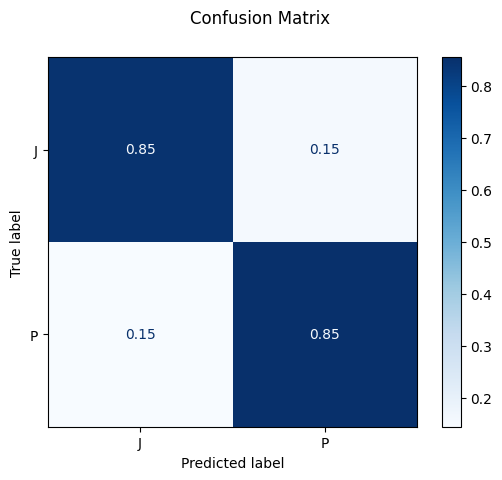

In [ ]:
# Source:
MBTI_subtype = ['ie', 'ns', 'tf', 'jp']
binary_models = {}

for subtype in MBTI_subtype:

  print(all_datasets[subtype].value_counts())

  encoder = LabelEncoder()
  y = encoder.fit_transform(all_datasets[subtype])

  # split into train and test sets
  # x_train, x_test, y_train, y_test = train_test_split(all_datasets['posts'], y, test_size=0.3)

  x_train, x_test, y_train, y_test = train_test_split(
      all_datasets['posts'], y,
      test_size=0.3,
      random_state=42,
      stratify=y  # "ensures that the training and testing sets have the same proportion of classes"
                  # "useful when dealing with imbalanced datasets"
      # source: https://medium.com/@aymuosmukherjee/why-do-we-use-stratify-in-train-test-split-e3eb296a5494
  )

  text_clf = Pipeline([
      ('tfidf', TfidfVectorizer(
            max_features=50000,   # max num of words accross all posts
            ngram_range=(1, 2),   # unigrams + bigrams('feel','feel like','like')
            sublinear_tf=True,    # replace tf with 1 + log(tf) (ignores repetitive words)
            min_df=3,             # word must appear in at least 3 posts
      )),

      ('clf',LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42,
            C=1.0,
      )),
  ])

  text_clf.fit(x_train, y_train)
  binary_models[subtype] = text_clf

  predicted = text_clf.predict(x_test)

  print(
      f"Classification report for {subtype} dataset:\n"
      f"{metrics.classification_report(y_test, predicted, target_names=encoder.classes_)}\n"
  )

  # Confusion Matrix
  disp = metrics.ConfusionMatrixDisplay.from_predictions(
      y_test,
      predicted,
      display_labels=encoder.classes_,
      cmap=plt.cm.Blues,
      normalize='true',
  )

  disp.figure_.suptitle("Confusion Matrix")

  plt.show()

In [ ]:
#import joblib
#import os
#
#os.makedirs('./kaggle/working/models', exist_ok=True)
#
#for subtype, model in binary_models.items():
#    joblib.dump(model, f'./kaggle/working/models/mbti_{subtype}.joblib')
#    print(f"Saved mbti_{subtype}.joblib")

In [ ]:
#from huggingface_hub import HfApi, login
#
#login()
#
#api = HfApi()
#
#api.create_repo(
#    repo_id="jhonatanparada499/binary-mbti-classifiers",
#    repo_type="model",
#    exist_ok=True
#)
#
#for fname in os.listdir('./kaggle/working/models'):
#    api.upload_file(
#        path_or_fileobj=f'./kaggle/working/models/{fname}',
#        path_in_repo=fname,
#        repo_id="jhonatanparada499/binary-mbti-classifiers",
#        repo_type="model"
#    )

In [ ]:
# 30% test size

print(len(y_test))

34164


In [ ]:
# confirm encoders
for subtype in ['ie', 'ns', 'tf', 'jp']:
    encoder = LabelEncoder()
    encoder.fit_transform(all_datasets[subtype])
    print(subtype, encoder.classes_)

ie ['E' 'I']
ns ['N' 'S']
tf ['F' 'T']
jp ['J' 'P']


[0] means E, [1] means I

In [28]:
ie_encoder = {0:'Extrovert',1:'Introvert'}

## Load Models

In [26]:
!hf download jhonatanparada499/binary-mbti-classifiers --local-dir ./

Fetching 5 files:   0% 0/5 [00:00<?, ?it/s]Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.

Fetching 5 files: 100% 5/5 [00:00<00:00, 19.80it/s]
Download complete: : 0.00B [00:00, ?B/s]              /content
Download complete: : 0.00B [00:00, ?B/s]


In [34]:
# for user text preprocessing
import joblib
import spacy
nlp = spacy.load("en_core_web_sm")

def preprocess(text):
    doc = nlp(text.lower())
    tokens = [token.lemma_ for token in doc
              if not token.is_punct and not token.is_space]
    return " ".join(tokens)

ie_model = joblib.load("./mbti_ie.joblib")

In [35]:
# Introvert sample
introvert = "I prefer staying home on weekends reading books alone. Large crowds drain my energy and I need quiet time to recharge after social interactions. I enjoy deep one on one conversations rather than group gatherings. Spending time by myself helps me think clearly and process my thoughts. I feel most productive working independently in a calm and silent environment."
extrovert = "I love going to parties and meeting new people every weekend. Being around others gives me energy and I thrive in loud and busy social environments. I enjoy working in teams and always look forward to group activities and events. Talking through my ideas out loud with others helps me think better. I get bored easily when I spend too much time alone and prefer to always be surrounded by friends."

i_input = preprocess(introvert)
print(f"tokens: {i_input}")
prediction = ie_model.predict([i_input])
print(f"prediction for introvert: {ie_encoder[prediction[0]]}")

e_input = preprocess(extrovert)
print(f"tokens: {e_input}")
prediction = ie_model.predict([e_input])
print(f"prediction for extrovert: {ie_encoder[prediction[0]]}")

tokens: I prefer stay home on weekend read book alone large crowd drain my energy and I need quiet time to recharge after social interaction I enjoy deep one on one conversation rather than group gathering spend time by myself help I think clearly and process my thought I feel most productive working independently in a calm and silent environment
prediction for introvert: Introvert
tokens: I love go to party and meet new people every weekend be around other give I energy and I thrive in loud and busy social environment I enjoy work in team and always look forward to group activity and event talk through my idea out loud with other help I think well I get bore easily when I spend too much time alone and prefer to always be surround by friend
prediction for extrovert: Extrovert
